### Dataset Description  

**Author: Danilo Dursoniah, data scientist, computational biologist**

**Date: 24/09/2025**

The dataset provided by VTT comprises experimental records obtained from an **ambr® cultivation platform**, which enables the parallel operation of multiple bioreactors. The data are organized into two main components:  

1. **Metadata file (`ambr.xlsx`)**  
   This file contains descriptive information about each cultivation experiment. It includes identifiers, initial conditions, vessel characteristics, cultivation setup, and measured variables. Each entry is associated with a specific bioreactor, denoted by a unique identifier (`Tunniste`, e.g., *AMBR_13*), which establishes the correspondence with the time-series data.  

2. **Time-series files (`ambr_run*.csv`)**  
   These files provide dynamic measurements collected throughout the cultivations. Each file corresponds to one experimental run, encompassing several parallel bioreactors. The temporal resolution is expressed in **hours**. For each bioreactor, a series of process parameters is reported, including but not limited to:  
   - **Gas flows and compositions** (air flow, off-gas CO₂%, oxygen uptake rate [OUR], carbon dioxide evolution rate [CER], respiratory quotient [RQ])  
   - **Culture conditions** (dissolved oxygen [DO], pH, temperature, stir speed, pressure)  
   - **Nutrient feeds** (flow rates and cumulative pumped volumes for each feed line)  
   - **Biomass proxies** (optical density, reflectance)  
   - **Reactor operation metrics** (liquid volume, acid/base additions, foam detection, sampling events).  

---

### Data Linking  

- Each **bioreactor** in the time-series files is designated as *Bioreactor XX* (e.g., *Bioreactor 13*).  
- The same identifier is present in the metadata file under the field `Tunniste` (*AMBR_13*), which provides the contextual information (e.g., organism, medium, initial optical density, starting volume).  
- The **experiment start date**, recorded in the metadata (`StartDate`), corresponds to the date encoded in the filename of the time-series files (e.g., `ambr_run1_140323` → 14 March 2023).  

---

### Units  

- **Volume**: millilitres (mL)  
- **Concentration**: grams per litre (g/L)  
- **Dissolved oxygen (DO)**: percentage of air saturation (%)  
- **Optical density (OD)**: dimensionless (typically measured at 600 nm)  
- **Gas composition (CO₂, O₂)**: percent volume fraction (%)  
- **CER / OUR**: millimoles per hour (mmol/h)  
- **RQ**: dimensionless ratio (CER/OUR)  
- **Stir speed**: revolutions per minute (rpm)  
- **Temperature**: degrees Celsius (°C)  
- **Pressure**: millibar (mbar) or pounds per square inch (psi), depending on calibration  

### ambr.xlsx

| Column                                     | Description                                           | Units              |
| ------------------------------------------ | ----------------------------------------------------- | ------------------ |
| `Tunniste`                                 | Bioreactor identifier (e.g. `AMBR_13`) → links to CSV | –                  |
| `StartDate`                                | Experiment start date                                 | YYYY-MM-DD         |
| `VesselType`                               | Vessel description (e.g. 250 mL ambr)                 | –                  |
| `VesselVolume`                             | Max working volume                                    | mL                 |
| `LiquidVolume`                             | Initial fill volume                                   | mL                 |
| `Organism`                                 | Organism cultivated                                   | –                  |
| `Strain`                                   | Strain identifier                                     | –                  |
| `Preculture`                               | Description of inoculum                               | –                  |
| `InitialOD`                                | Starting optical density                              | OD (dimensionless) |
| `ShakingRotationDiameter`                  | Orbital shaker diameter                               | mm                 |
| `ShakerRPM`                                | Agitation speed                                       | rpm                |
| `Temperature`                              | Set incubation temperature                            | °C                 |
| `Humidity`                                 | Ambient humidity                                      | %                  |
| `CultivationType`                          | Batch / Fed-batch / etc.                              | –                  |
| `CarbonSource`                             | Substrate fed                                         | –                  |
| `InitialConcentration(g/L)`                | Initial concentration of carbon source                | g/L                |
| `Medium`                                   | Medium used                                           | –                  |
| `InitialPH`                                | Starting pH                                           | –                  |
| `CultivationTime`                          | Planned cultivation length                            | h                  |
| `MeasPH`, `MeasOD`, `MeasDO`, `MeasGas`, … | Flags indicating if these were measured               | Y/N                |


### ambr_run*.csv

| Column suffix                 | Description                                              | Units                       |
| ----------------------------- | -------------------------------------------------------- | --------------------------- |
| `Acid volume pumped`          | Cumulative acid addition (for pH control)                | mL                          |
| `Base volume pumped`          | Cumulative base addition                                 | mL                          |
| `Air flow`                    | Gas inlet flow                                           | sccm or mL/min              |
| `Bioreactor pressure reading` | Headspace pressure                                       | mbar or psi                 |
| `CER`                         | CO₂ evolution rate                                       | mmol/h (sometimes mmol/L/h) |
| `OUR`                         | O₂ uptake rate                                           | mmol/h                      |
| `RQ`                          | Respiratory quotient (CER/OUR)                           | –                           |
| `DO`                          | Dissolved oxygen                                         | % air saturation            |
| `Feed#1/2 flow rate`          | Feed pump instantaneous flow                             | mL/h (or mL/min)            |
| `Feed#1/2 volume pumped`      | Cumulative feed delivered                                | mL                          |
| `Foam sensor`                 | Foam detection (instrument-specific)                     | –                           |
| `Off-gas CO₂%`                | Exhaust gas CO₂ concentration                            | % vol                       |
| `Optical density`             | Biomass proxy                                            | OD (dimensionless)          |
| `Reflectance`                 | Biomass proxy (backscatter)                              | arbitrary units             |
| `pH`                          | Measured pH (no control here)                            | –                           |
| `Sampling events`             | Log of when samples were taken                           | –                           |
| `Stir speed`                  | Agitator speed                                           | rpm                         |
| `Temperature`                 | Bioreactor broth temperature                             | °C                          |
| `Volume`                      | Liquid volume in reactor (changes with feeding/sampling) | mL                          |

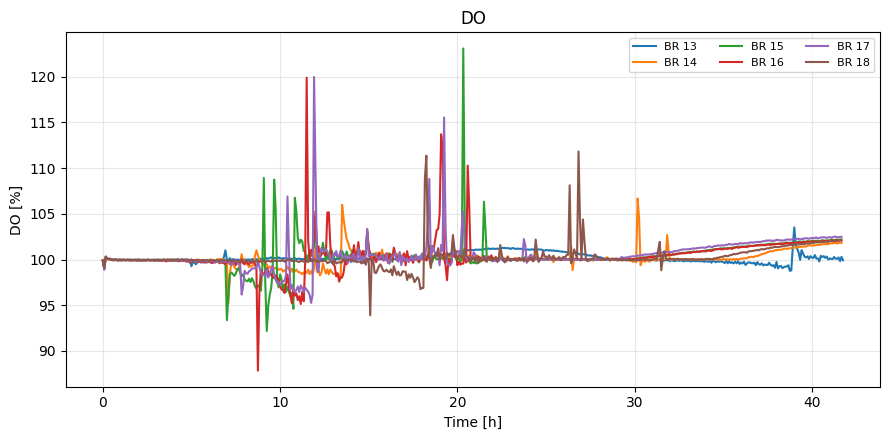

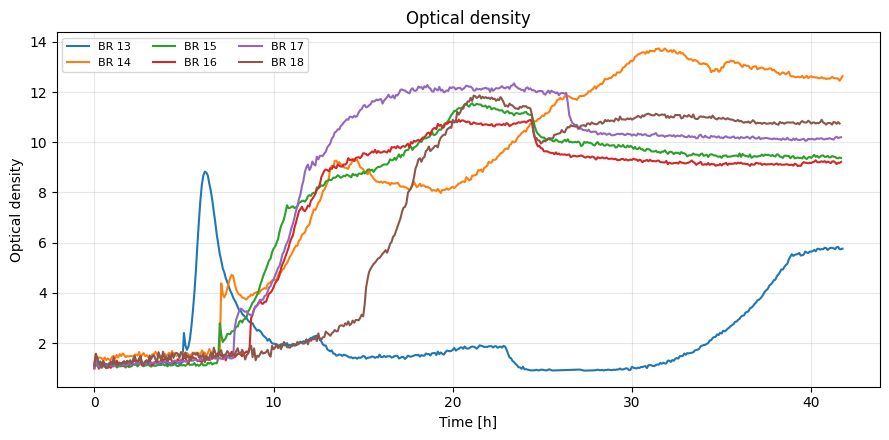

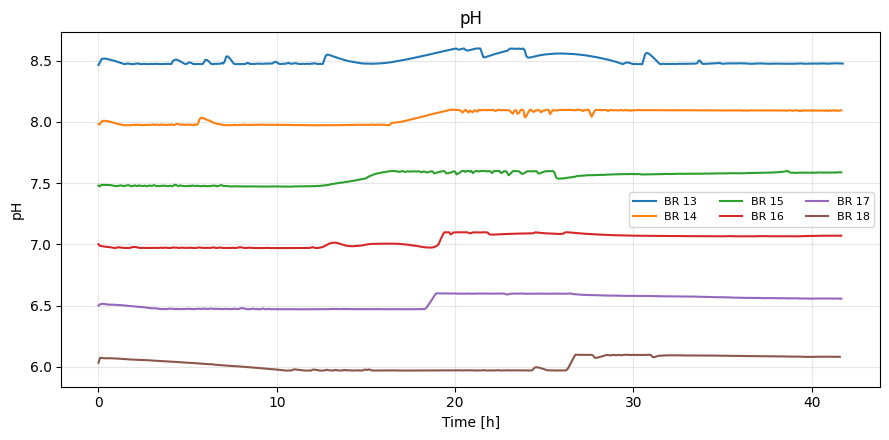

In [1]:
from ambr_plotter import load_metadata, load_runs, link_metadata, plot_timeseries,load_tidy_ambr

df = load_tidy_ambr("ambr_tidy_timeseries.csv")

plot_timeseries(
    df,
    variables=["DO", "Optical density","pH"],
    bioreactors=[13,14,15,16,17,18],
    run="ambr_run1_140323_13-18"
)